# Linear model selection and regularization
In a regression the gaol is to find a model which relates the predictors X to the response Y by fitting model parameters $\beta$
e.g.

$$
Y = \beta_0 + \beta_1 X_1 + ... \beta_p X_p 
$$

Normally least squares is used to estimate or fit the parameters $\beta$. As long as the number of observations n is ways larger then the number of predictors p, n>>p least squares results in low variance and low bias but if n and p close to be the same size the variability rises and least squares tend to overfit on the train data. If in a more extreme case p>n least squares cant find a unique solution anymore. By **constraining** or **shrinking** the estimated coefficients the model variability can be decreased while increasing the bias in a neglectable way.

Furthermore the model interpretability can be increased if we find predictors which do not contribute to the response Y and thus can be seen as irrelevant and we can reduce the model complexity by either down weighting this predictors or even remove them to have a better situation for n vs. p.

Three methods will be investigated in this notebook:
1. Subset Selection: Select only a subset of the predictors p that relate to the response
2. Shrinkage: Fitting models with all p predictors but the estimated coefficients are shrunken towards 0 relative to the least squares estimates. This shrinkage also called regularization leads to lower variance if coefficients reach 0 shrinkage methods also can be used to perform subset selection.
3. Dimension Reduction: Projecting p predictors into an M-dimensional subspace where M < p by computing M linear combinations of p. Then model fitting is performed in the M space

# Subset selection

## Best subset selection
The idea of best subset selection is to find the best subset of predictors by fitting all possible models with a combination of the p predictors. This results in 2^p potential models which need to be tried or for each combination k of p predictors $\frac{p}{k}$ = p(p-1)/k potential models.

The algorithm works as follows:
1. Start with the $M_0$ model which hold only the intercept and is equal to the mean of the distribution
2. For k=1,2,...p
fit all models $\frac{p}{k}$ Mk and find the best with the lowest RSS or biggest R^2
3. Select a single best model from Mk using the prediction error on the validation set Cp BIC, AIC or another cross validation method

   Unnamed: 0   Income  Limit  Rating  Cards  Age  Education  Gender Student  \
0           1   14.891   3606     283      2   34         11    Male      No   
1           2  106.025   6645     483      3   82         15  Female     Yes   
2           3  104.593   7075     514      4   71         11    Male      No   
3           4  148.924   9504     681      3   36         11  Female      No   
4           5   55.882   4897     357      2   68         16    Male      No   

  Married  Ethnicity  Balance  
0     Yes  Caucasian      333  
1     Yes      Asian      903  
2      No      Asian      580  
3      No      Asian      964  
4     Yes  Caucasian      331  
Total iterations: 63
Test MSE for best subset models of different sizes: {1: np.float64(68340.88053675967), 2: np.float64(28914.52539641909), 3: np.float64(31221.62597218973), 4: np.float64(31065.4779706177), 5: np.float64(29878.076608331634), 6: np.float64(29863.873501581296)}


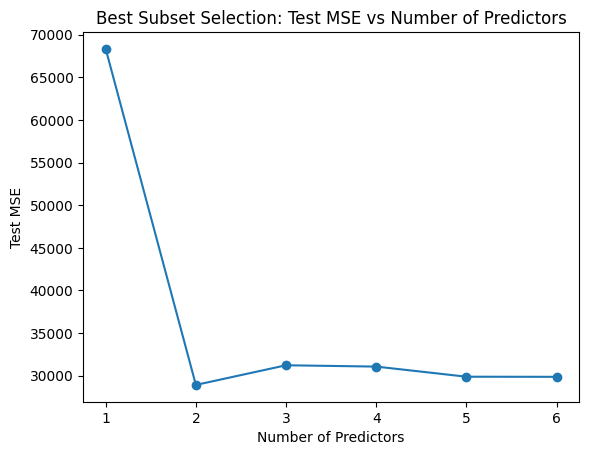

Best model uses 2 predictors: (0, 2) with Test MSE: 25725.575906919876
Coefficients of the best model: [-7.67212437  3.94926483]


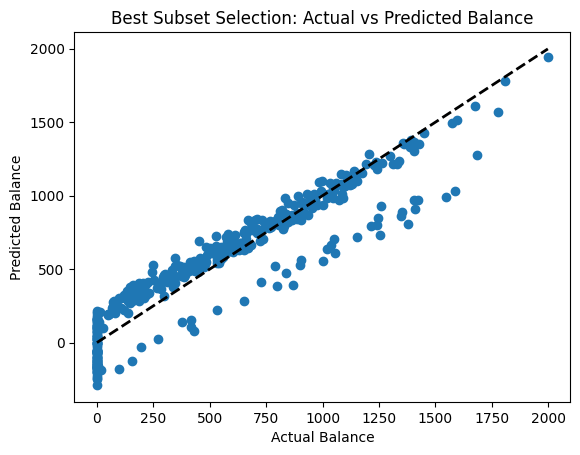

In [4]:
## Linear Model Selection using the best subset selection
#1. load the Credit dataset from the ISLR package.
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from itertools import combinations
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Load the Credit dataset
df = pd.read_csv("data/Credit.csv")
print(df.head())
# Prepare the feature matrix X and response vector y
X = df[["Income", "Limit", "Rating", "Cards", "Age", "Education"]]
y = df["Balance"]
# we have 6 predictors so we will have 2^6 = 64 possible models

# split the data into training and testing sets
    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def best_subset_selection(X, y):
    itterations = 0
    n, p = X.shape
    best_models = {}
    for k in range(1, p + 1):
        
        best_mse = float('inf')
        best_combination = None
        for combo in combinations(range(p), k):
            itterations += 1
            X_subset = X.iloc[:, list(combo)]
            model = LinearRegression().fit(X_subset, y)
            y_pred = model.predict(X_subset)
            mse = np.mean((y - y_pred) ** 2) # RSS / n
            if mse < best_mse:
                best_mse = mse
                best_combination = combo
        best_models[k] = (best_combination, best_mse)
    print("Total iterations:", itterations)
    return best_models

best_models = best_subset_selection(X_train, y_train)

# Evaluate the best models on the test set
test_mse = {}
for k, (combo, _) in best_models.items():
    X_subset_test = X_test.iloc[:, list(combo)]
    model = LinearRegression().fit(X_train.iloc[:, list(combo)], y_train)
    y_pred_test = model.predict(X_subset_test)
    mse_test = np.mean((y_test - y_pred_test) ** 2)
    test_mse[k] = mse_test
    
print("Test MSE for best subset models of different sizes:", test_mse)
# Plot test MSE against number of predictors

plt.plot(list(test_mse.keys()), list(test_mse.values()), marker='o')
plt.xlabel('Number of Predictors')
plt.ylabel('Test MSE')
plt.title('Best Subset Selection: Test MSE vs Number of Predictors')
plt.show()

# Print the best model with the lowest test MSE
best_k = min(test_mse, key=test_mse.get)
best_combo, best_mse = best_models[best_k]
print(f"Best model uses {best_k} predictors: {best_combo} with Test MSE: {best_mse}")

# fit the best model on the entire dataset and print the coefficients
final_model = LinearRegression().fit(X.iloc[:, list(best_combo)], y)
print("Coefficients of the best model:", final_model.coef_)

# Plot the fit of the best model
y_pred_final = final_model.predict(X.iloc[:, list(best_combo)])
plt.scatter(y, y_pred_final)
plt.xlabel('Actual Balance')
plt.ylabel('Predicted Balance')
plt.title('Best Subset Selection: Actual vs Predicted Balance')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()
    


# Stepwise selection
The main limitation of the best subset selection method is the computational cost as the number of models to investigate rises exponentially with the number of predictors. Therefore a step wise approaches which restrict the set of models are alternative approaches.

## Forward step stepwise selection
Forward stepwise selection starts with the minimum model Mo which contains no predictors and then step by step add one predictor. For each step all predictors are tested and the best one is keept fixed then the best second one will be added etc.

The algorithm works as follows:
1. Start with the null model Mo which predicts the mean
2. For k= 0 ... p
- choose all k-p models that add one predictor to Mk
- select the best predictor with the lowest RSS or highest R^2
3. from all Mk selected models select the single best model using cross validation e.g. minimizing the prediction error on the test set

Total iterations: 21
Test MSE for forward stepwise models of different sizes: {1: np.float64(68340.88053675967), 2: np.float64(28914.525396419085), 3: np.float64(29289.344884929335), 4: np.float64(30049.06915666418), 5: np.float64(29878.076608332405), 6: np.float64(29863.873501581977)}


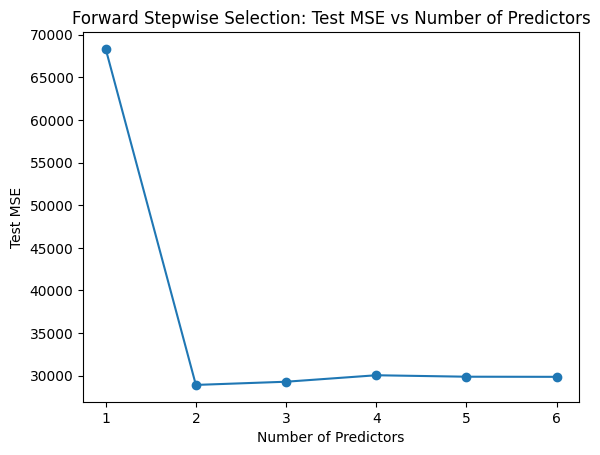

Best model uses 2 predictors: [2, 0] with Test MSE: 25725.575906919876
Coefficients of the best model: [ 3.94926483 -7.67212437]


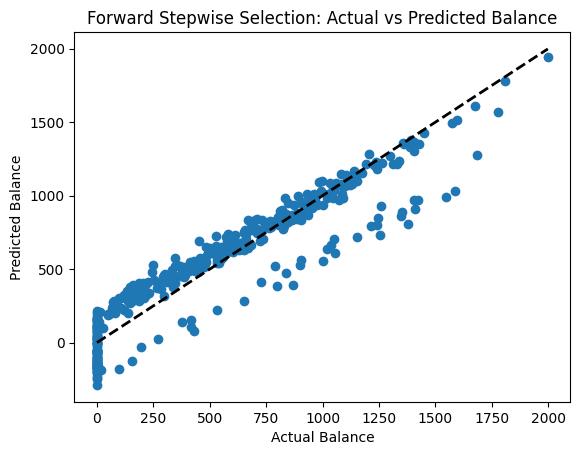

In [5]:
## Forward stepwise selection
# The idea of forward stepwise selection is to start with no predictors and add them one by
# one, at each step adding the predictor that improves the model the most until no further improvement is possible.

# Lets use again the credit dataset and implement forward stepwise selection to select the best model.
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from itertools import combinations
# load the Credit dataset
df = pd.read_csv("data/Credit.csv")
X = df[["Income", "Limit", "Rating", "Cards", "Age", "Education"]]
y = df["Balance"]

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Forward stepwise selection function


def forward_stepwise_selection(X, y):
    n, p = X.shape
    itterations = 0
    selected_features = []
    remaining_features = list(range(p))
    best_models = {}
    
    for k in range(1, p + 1):
        best_mse = float('inf')
        best_feature = None
        
        for feature in remaining_features:
            itterations += 1
            current_features = selected_features + [feature]
            X_subset = X.iloc[:, current_features]
            model = LinearRegression().fit(X_subset, y)
            y_pred = model.predict(X_subset)
            mse = np.mean((y - y_pred) ** 2)
            
            if mse < best_mse:
                best_mse = mse
                best_feature = feature
                
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        best_models[k] = (selected_features.copy(), best_mse)
    print("Total iterations:", itterations)
    return best_models

best_models = forward_stepwise_selection(X_train, y_train)
# Evaluate the best models on the test set
test_mse = {}
for k, (features, _) in best_models.items():
    X_subset_test = X_test.iloc[:, features]
    model = LinearRegression().fit(X_train.iloc[:, features], y_train)
    y_pred_test = model.predict(X_subset_test)
    mse_test = np.mean((y_test - y_pred_test) ** 2)
    test_mse[k] = mse_test
print("Test MSE for forward stepwise models of different sizes:", test_mse)
# Plot test MSE against number of predictors
plt.plot(list(test_mse.keys()), list(test_mse.values()), marker='o')
plt.xlabel('Number of Predictors')
plt.ylabel('Test MSE')
plt.title('Forward Stepwise Selection: Test MSE vs Number of Predictors')
plt.show()
# Print the best model with the lowest test MSE
best_k = min(test_mse, key=test_mse.get)
best_features, best_mse = best_models[best_k]
print(f"Best model uses {best_k} predictors: {best_features} with Test MSE: {best_mse}")
# fit the best model on the entire dataset and print the coefficients
final_model = LinearRegression().fit(X.iloc[:, best_features], y)
print("Coefficients of the best model:", final_model.coef_)
# Plot the fit of the best model
y_pred_final = final_model.predict(X.iloc[:, best_features])
plt.scatter(y, y_pred_final)
plt.xlabel('Actual Balance')
plt.ylabel('Predicted Balance')
plt.title('Forward Stepwise Selection: Actual vs Predicted Balance')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()

# Backward Stepwise selection
Backward stepwise selection works the same as forward stepwise selection but we start with a model M0 containing all predictors p and we step wise remove the predictor p which has the lowest impact meaning the lowest increase of the error. Like in forward selection we try all predictors per step k and keep the best subset of predictors p.



Total iterations: 20


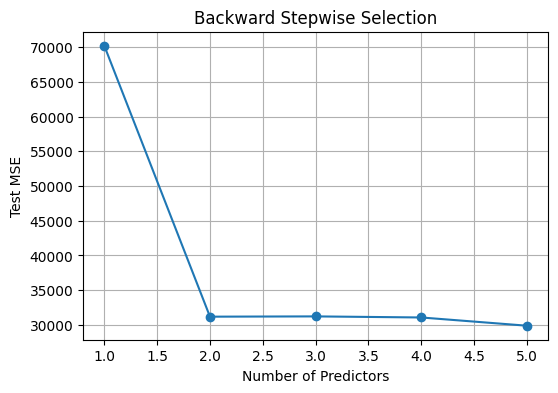

Best model uses 5 predictors:
Index(['Income', 'Limit', 'Rating', 'Cards', 'Age'], dtype='object')
Final model coefficients:
Income: -7.562
Limit: 0.129
Rating: 2.022
Cards: 11.553
Age: -0.888


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("data/Credit.csv")
X = df[["Income", "Limit", "Rating", "Cards", "Age", "Education"]]
y = df["Balance"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def backward_stepwise_selection(X, y):
    n, p = X.shape
    selected_features = list(range(p))
    best_models = {}
    iterations = 0

    # Stop at 1 predictor (not 0!)
    for k in range(p, 1, -1):
        best_mse = np.inf
        feature_to_remove = None

        for feature in selected_features:
            iterations += 1
            candidate_features = selected_features.copy()
            candidate_features.remove(feature)

            X_subset = X.iloc[:, candidate_features]
            model = LinearRegression().fit(X_subset, y)
            y_pred = model.predict(X_subset)
            mse = np.mean((y - y_pred) ** 2)

            if mse < best_mse:
                best_mse = mse
                feature_to_remove = feature

        selected_features.remove(feature_to_remove)
        best_models[len(selected_features)] = (
            selected_features.copy(),
            best_mse
        )

    print("Total iterations:", iterations)
    return best_models

# Run backward stepwise selection
best_models = backward_stepwise_selection(X_train, y_train)

# Evaluate models on test set
test_mse = {}
for k, (features, _) in best_models.items():
    model = LinearRegression().fit(X_train.iloc[:, features], y_train)
    y_pred_test = model.predict(X_test.iloc[:, features])
    test_mse[k] = np.mean((y_test - y_pred_test) ** 2)

# Plot test MSE
plt.figure(figsize=(6,4))
plt.plot(list(test_mse.keys()), list(test_mse.values()), marker='o')
plt.xlabel("Number of Predictors")
plt.ylabel("Test MSE")
plt.title("Backward Stepwise Selection")
plt.grid(True)
plt.show()

# Best model
best_k = min(test_mse, key=test_mse.get)
best_features, _ = best_models[best_k]

print(f"Best model uses {best_k} predictors:")
print(X.columns[best_features])

# Fit final model
final_model = LinearRegression().fit(X.iloc[:, best_features], y)
print("Final model coefficients:")
for name, coef in zip(X.columns[best_features], final_model.coef_):
    print(f"{name}: {coef:.3f}")


# Best model selection

We described now several methods to select the best model based on subsets forward and backward search. So far we used the MSE on the testset as indication of model quality. This leads to interesting results. In the approaches best model selection and forward subset selection the best model was found using parameter 0,2 while in the backward selection we found 0,1,2,3,4,5 which is the full model. Therefor we should take a deeper look into metrics how to rate a models quality. 

The RSS or MSE=RSS/n will always decrease with more model parameters in the train set but not automatically in the test set. More concret the test error even can increase with a more flexible model in the test set. Therefor the reduction in model size needs to be taken into account in a metric as additional weighting of model complexity in the error metric. 

The four typical approaches are:
1. $C_p$ 
2. AIC (Akaike information criteria)
3. BIC (Bayes information criteria)
4. Adjusted $R^2$

$C_p$ is calculated using 

$$
C_p = 1/n (RSS + 2d \sigma^2)
$$
where d is the number of predictors p and $\sigma^2$ is the estimated error normally obtained from the full model with all predictors. Therefor more complex model with more flexibility get penalized by having d in the equation. $C_p$ is an unbiased estimator of the test MSE.

AIC is calulated similar to $C_p$ 

$$
AIC = 1/n (RSS + 2d \sigma^2)
$$

and for least squares regression is thus the same. 

BIC is derived from a bayesian viewpoint but for least square regression its quite similar to AIC and $C_p$

$$
BIC = 1/n (RSS + log(n)d \sigma^2)
$$

with n is the number of observations therefore BIC places heavier penalty on more complex models. 

Finally the addjusted $R^2$ is given by the 
$$
R^2 = 1- \frac{RSS}{TSS}
$$

where TSS is the total sum of squares for the response. 

The adjusted version is 

$$
Adjusted R^2 = 1- \frac{RSS/(n-d-1)}{TSS(n-1)}
$$

In contrast to AIC and BIC and $C_p$ the Adjusted $R^2$ is maximized for the best performing model.

In [ ]:
## Calculate AIC, BIC and adj-R² for model selection
# Function to calculate AIC, BIC, and adjusted R²

def AIC(model, X, y, sigma):
    n = len(y)
    d = X.shape[1]
    residuals = y - model.predict(X)
    rss = np.sum(residuals ** 2)
    aic = 1/n * (rss + 2 * d * sigma) # 6.2
    return aic

def BIC(model, X, y, sigma):
    n = len(y)
    d = X.shape[1]
    residuals = y - model.predict(X)
    rss = np.sum(residuals ** 2)
    bic = 1/n * (rss + np.log(n) * d * sigma) # 6.3
    return bic

def adjusted_R2(model, X, y):
    n = len(y)
    d = X.shape[1]
    TSS = np.sum((y - np.mean(y)) ** 2)
    RSS = np.sum((y - model.predict(X)) ** 2)
    r2 = 1 - RSS / TSS
    adj_r2 = 1  - (RSS/(n - d - 1)) / (TSS/(n - 1)) # 6.4
    return adj_r2

# Example usage with the Credit dataset
df = pd.read_csv("data/Credit.csv")
X = df[["Income", "Limit", "Rating", "Cards", "Age", "Education"]]
y = df["Balance"]
# make a full model search using best subset selection
best_models = best_subset_selection(X, y) # from previous code

# estimate sigma^2 using the full model
full_model = LinearRegression().fit(X, y)
y_pred_full = full_model.predict(X)
sigma2 = np.mean((y - y_pred_full) ** 2)
sigma = np.sqrt(sigma2)
print("Estimated sigma:", sigma)
# Calculate AIC, BIC, and adjusted R² for each model
model_selection_metrics = {}

 
for k, (features, _) in best_models.items():
    print("Evaluating model with features:", features)
    X_subset = X.iloc[:, list(features)]
    model = LinearRegression().fit(X_subset, y)
    aic = AIC(model, X_subset, y, sigma)
    bic = BIC(model, X_subset, y, sigma)
    adj_r2 = adjusted_R2(model, X_subset, y)
    model_selection_metrics[k] = {
        "AIC": aic,
        "BIC": bic,
        "Adjusted R²": adj_r2
    }
# Print the metrics
for k, metrics in model_selection_metrics.items():
    print(f"Model with {k} predictors: AIC={metrics['AIC']:.3f}, BIC={metrics['BIC']:.3f}, Adjusted R²={metrics['Adjusted R²']:.3f}")
## Plot the metrics vs number of predictors
aic_values = [metrics["AIC"] for metrics in model_selection_metrics.values()]
bic_values = [metrics["BIC"] for metrics in model_selection_metrics.values()]
adj_r2_values = [metrics["Adjusted R²"] for metrics in model_selection_metrics.values()]
num_predictors = list(model_selection_metrics.keys())
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(num_predictors, aic_values, marker='o')
plt.xlabel('Number of Predictors')
plt.ylabel('AIC')
plt.title('AIC vs Number of Predictors')
plt.subplot(1, 3, 2)
plt.plot(num_predictors, bic_values, marker='o')
plt.xlabel('Number of Predictors')
plt.ylabel('BIC')
plt.title('BIC vs Number of Predictors')
plt.subplot(1, 3, 3)
plt.plot(num_predictors, adj_r2_values, marker='o')
plt.xlabel('Number of Predictors')
plt.ylabel('Adjusted R²')
plt.title('Adjusted R² vs Number of Predictors')
plt.tight_layout()
plt.show()

Total iterations: 63
Estimated sigma: 160.22469571901843
Evaluating model with features: (2,)


IndexingError: Too many indexers